# 04 · Multi-peak 3D geolocation candidates

**Research question.** What coordinates result when real non-refh waveform components are mapped with the available segment and beam geometry, and what checks support or limit those coordinates?

Every candidate here is experimental. The segment method interpolates `rwstart` to `rwstop` in ECEF using `peak_bin / (n_rx_bins - 1)`. The beam method uses an audited local angle convention and steps from the official refh point by `(peak_bin - raw_argmax_bin) * bin_size`; it is anchored to refh by construction. The module computes coordinates for existing detector outputs and never reruns the detector itself.

## Paths and bounded real sample

This notebook runs independently of the waveform notebook. It re-extracts only sweeps 5000–5002 from the explicit 2024-11-18 H5, then runs the shared locator and validator.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from IPython.display import display
from pyproj import Transformer
from casals_l1b.peaks_cli import default_config, extract_components
from casals_l1b.geolocation import locate_peaks, validate_candidate_table

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Run this notebook from the CASALS repository root.")
H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241118T171757_001_02.h5"
SWEEPS = [5000, 5001, 5002]
OUTPUT_ROOT = ROOT / "outputs/notebooks/04_peak_geolocation"
PEAK_ROOT = OUTPUT_ROOT / "peak_extraction"
GEOMETRY_ROOT = OUTPUT_ROOT / "geometry_both_methods"
VALIDATION_ROOT = OUTPUT_ROOT / "candidate_validation"
if not H5_PATH.exists():
    raise FileNotFoundError(f"Missing CASALS H5: {H5_PATH}")
print("H5:", H5_PATH.relative_to(ROOT), "| sweeps:", SWEEPS)

H5: data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5 | sweeps: [5000, 5001, 5002]


## Extract and locate real waveform components

The component table is generated with the shared detector and passed to the locator. The segment and beam models are both run so each pulse/component pair can be compared directly.

In [2]:
run_config = default_config([H5_PATH], PEAK_ROOT)
extracted = extract_components(H5_PATH, sweep_selection=SWEEPS,
                               config=run_config, output_dir=PEAK_ROOT)
located = locate_peaks(H5_PATH, extracted["component_table"], GEOMETRY_ROOT, method="both")
validated = validate_candidate_table(H5_PATH, located["candidate_points"], VALIDATION_ROOT)
components = pd.read_parquet(extracted["component_table"])
candidates = pd.read_parquet(located["candidate_points"])
closure = pd.read_csv(located["closure_residuals"])
validation_summary = pd.read_csv(located["validation_summary"])
audit_summary = pd.read_csv(validated["validation_summary"])
print(f"Pulses with detector output: {components.pulse_index.nunique():,}")
print(f"Component rows: {len(components):,}; candidate rows: {len(candidates):,}")
display(audit_summary)

H5: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5
Output dir: C:\Users\zhong267\OneDrive - purdue.edu\CASALS\outputs\notebooks\04_peak_geolocation\peak_extraction\casals_l1b_20241118T171757_001_02
Selected sweeps: [5000, 5001, 5002]


Processing sweep 5000: valid_tracks=256, missing_tracks=0


Finished sweep 5000: pulses=256, components=1034, median prominent=2.00


Processing sweep 5001: valid_tracks=256, missing_tracks=0


Finished sweep 5001: pulses=256, components=959, median prominent=1.00


Processing sweep 5002: valid_tracks=256, missing_tracks=0


Finished sweep 5002: pulses=256, components=1071, median prominent=2.00


Pulses with detector output: 766
Component rows: 3,064; candidate rows: 6,128


,scope,method,n_total,n_valid,valid_fraction,n_pulse_identity_mismatch,n_coordinate_status_mismatch,status,note
0,candidate_table,beam_refh_anchor_stored_bin_size,3064,3064,1.0,0,0,pass,schema and H5 sweep/track identity checks; geo...
1,candidate_table,segment_rwstart_to_rwstop_linear_bin_fraction,3064,3064,1.0,0,0,pass,schema and H5 sweep/track identity checks; geo...


## Refh closure from raw RX argmax

For each pulse with at least one component row, the locator interpolates `rwstart` to `rwstop` at the raw RX argmax bin and compares the result with refh. This check is independent of detector component rank and uses no fitted parameters, but it is still an internal consistency check against the same L1B product, not external geolocation accuracy.

,scope,method,3d_count,3d_median,3d_p90,3d_p95,n_total,n_valid,valid_fraction,note,...,sweep_num,xyz_discrepancy_count_m,xyz_discrepancy_median_m,xyz_discrepancy_p90_m,xyz_discrepancy_p95_m,n_common,implied_bin_size_median_m,stored_bin_size_median_m,difference_median_m,difference_p95_abs_m
0,refh_closure,segment_rwstart_to_rwstop_linear_bin_fraction,766.0,0.016591,0.017639,0.028597,766.0,766.0,1.0,raw RX argmax bin; no fitted parameters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,refh_closure,segment_rwstart_to_rwstop_linear_bin_fraction,NaN,NaN,NaN,NaN,766.0,766.0,1.0,raw RX argmax bin; no fitted parameters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,refh_closure,segment_rwstart_to_rwstop_linear_bin_fraction,NaN,NaN,NaN,NaN,766.0,766.0,1.0,raw RX argmax bin; no fitted parameters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,candidate_geometry,beam_refh_anchor_stored_bin_size,NaN,NaN,NaN,NaN,3064.0,3064.0,1.0,valid means finite modeled coordinates; not in...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,candidate_geometry,segment_rwstart_to_rwstop_linear_bin_fraction,NaN,NaN,NaN,NaN,3064.0,3064.0,1.0,valid means finite modeled coordinates; not in...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,beam_segment_agreement,segment_vs_beam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,internal method agreement only; beam candidate...,...,NaN,3064.0,0.057463,0.207807,0.236448,3064.0,NaN,NaN,NaN,NaN
9,bin_mapping,segment_length_over_n_bins_minus_1_vs_stored_b...,NaN,NaN,NaN,NaN,766.0,766.0,NaN,stored bin_size is interpreted in meters from ...,...,NaN,NaN,NaN,NaN,NaN,NaN,0.14991,0.149738,0.000172,0.000175


Valid raw-argmax closures: 766 / 766


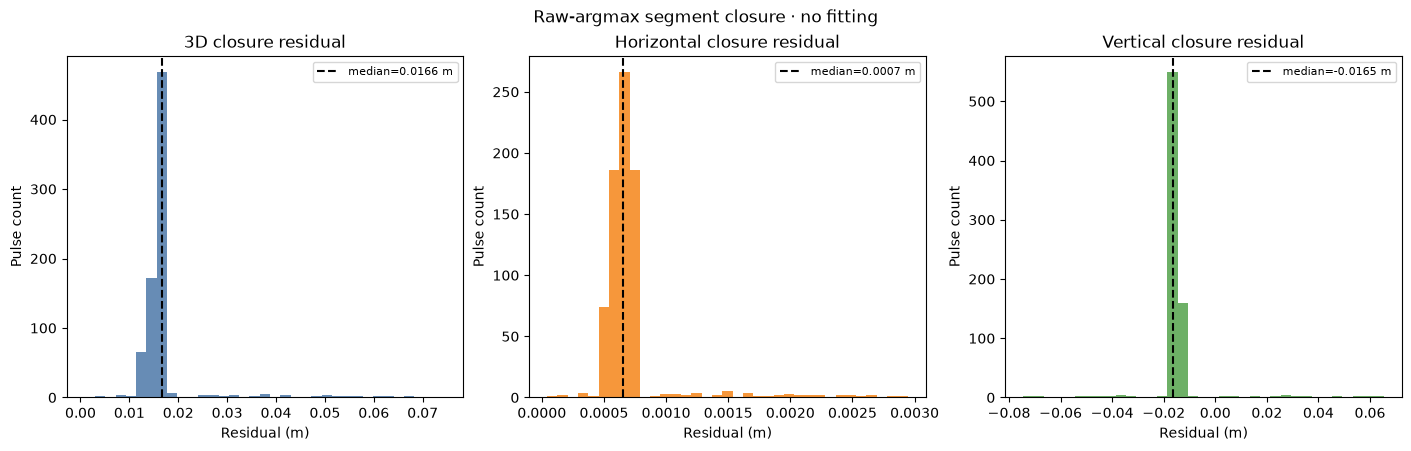

,sweep_num,n,median_3d_m,p95_3d_m,median_horizontal_m,median_vertical_m
0,5000,256,0.016591,0.017998,0.000655,-0.016523
1,5001,255,0.016591,0.020645,0.000655,-0.016523
2,5002,255,0.016646,0.036441,0.000656,-0.016358


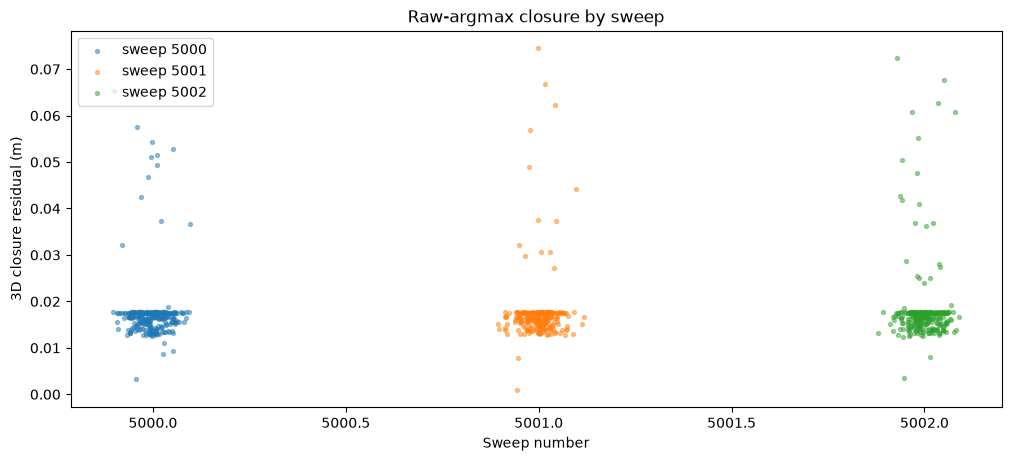

In [3]:
valid_closure = closure.loc[closure["status"] == "ok"].copy()
closure_summary = validation_summary[validation_summary["scope"].isin(
    ["refh_closure", "bin_mapping", "beam_segment_agreement", "candidate_geometry"])]
display(closure_summary)
print(f"Valid raw-argmax closures: {len(valid_closure):,} / {len(closure):,}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for ax, col, title, color in [
    (axes[0], "error_3d_m", "3D closure residual", "#4c78a8"),
    (axes[1], "horizontal_error_m", "Horizontal closure residual", "#f58518"),
    (axes[2], "vertical_difference_m", "Vertical closure residual", "#54a24b"),
]:
    values = valid_closure[col].to_numpy(dtype=float)
    ax.hist(values, bins=35, color=color, alpha=.85)
    ax.axvline(np.median(values), color="black", linestyle="--", label=f"median={np.median(values):.4f} m")
    ax.set(xlabel="Residual (m)", ylabel="Pulse count", title=title)
    ax.legend(fontsize=8)
fig.suptitle("Raw-argmax segment closure · no fitting")
plt.show()

by_sweep = valid_closure.groupby("sweep_num").agg(
    n=("error_3d_m", "size"), median_3d_m=("error_3d_m", "median"),
    p95_3d_m=("error_3d_m", lambda x: x.quantile(.95)),
    median_horizontal_m=("horizontal_error_m", "median"),
    median_vertical_m=("vertical_difference_m", "median"),
).reset_index()
display(by_sweep)
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for sweep, group in valid_closure.groupby("sweep_num"):
    jitter = np.random.default_rng(int(sweep)).normal(0, .04, len(group))
    ax.scatter(np.full(len(group), sweep) + jitter, group["error_3d_m"],
               s=8, alpha=.45, label=f"sweep {sweep}")
ax.set(xlabel="Sweep number", ylabel="3D closure residual (m)",
       title="Raw-argmax closure by sweep")
ax.legend()
plt.show()

## Segment versus beam candidates

Paired differences use identical `(pulse_index, component_rank)` rows. Agreement between two models is a comparison, not independent confirmation: the beam candidates are explicitly refh-anchored.

,geolocation_method,geometry_valid,geometry_status,rows
0,beam_refh_anchor_stored_bin_size,True,ok,3064
1,segment_rwstart_to_rwstop_linear_bin_fraction,True,ok,3064


Paired finite candidates: 3,064
Segment/beam ECEF discrepancy (m): {'median': 0.057463389117620306, 'p90': 0.20780736207651695, 'p95': 0.23644799367733865}


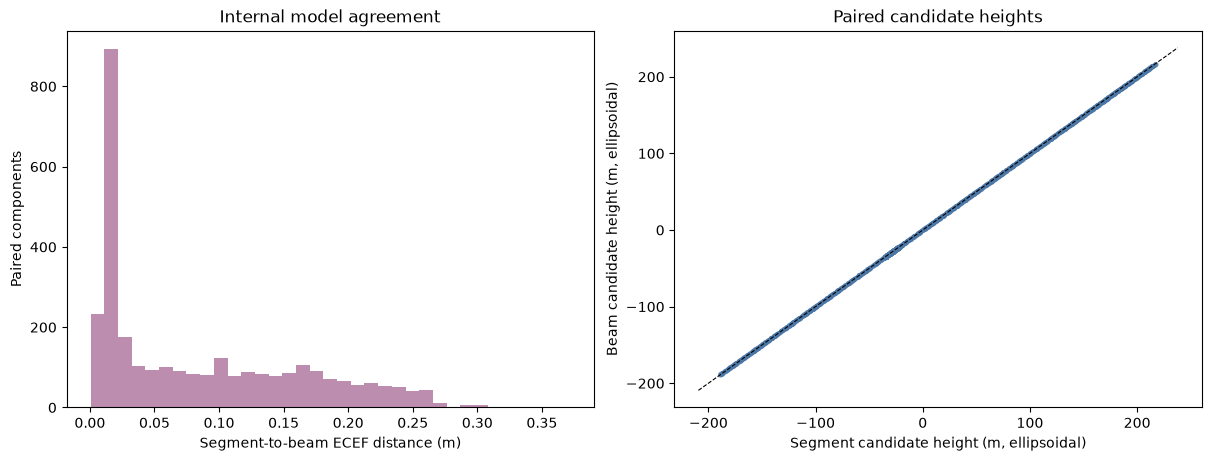

In [4]:
valid = candidates[candidates["geometry_valid"].astype(bool)].copy()
method_counts = candidates.groupby(["geolocation_method", "geometry_valid", "geometry_status"]).size().rename("rows").reset_index()
display(method_counts)
paired = candidates.pivot_table(
    index=["pulse_index", "component_rank"], columns="geolocation_method",
    values=["candidate_x", "candidate_y", "candidate_z", "candidate_height", "geometry_valid"],
    aggfunc="first",
)
from casals_l1b.geolocation import SEGMENT_METHOD, BEAM_METHOD
both_ok = (paired[("geometry_valid", SEGMENT_METHOD)].fillna(False).astype(bool)
           & paired[("geometry_valid", BEAM_METHOD)].fillna(False).astype(bool))
delta = np.sqrt(
    (paired.loc[both_ok, ("candidate_x", SEGMENT_METHOD)] - paired.loc[both_ok, ("candidate_x", BEAM_METHOD)])**2
    + (paired.loc[both_ok, ("candidate_y", SEGMENT_METHOD)] - paired.loc[both_ok, ("candidate_y", BEAM_METHOD)])**2
    + (paired.loc[both_ok, ("candidate_z", SEGMENT_METHOD)] - paired.loc[both_ok, ("candidate_z", BEAM_METHOD)])**2
)
print(f"Paired finite candidates: {int(both_ok.sum()):,}")
print("Segment/beam ECEF discrepancy (m):",
      {"median": float(delta.median()), "p90": float(delta.quantile(.90)), "p95": float(delta.quantile(.95))})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].hist(delta, bins=35, color="#b279a2", alpha=.85)
axes[0].set(xlabel="Segment-to-beam ECEF distance (m)", ylabel="Paired components",
            title="Internal model agreement")
axes[1].scatter(paired.loc[both_ok, ("candidate_height", SEGMENT_METHOD)],
                paired.loc[both_ok, ("candidate_height", BEAM_METHOD)],
                s=7, alpha=.35, color="#4c78a8")
lo = min(axes[1].get_xlim()[0], axes[1].get_ylim()[0])
hi = max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])
axes[1].plot([lo, hi], [lo, hi], "k--", lw=.8)
axes[1].set(xlabel="Segment candidate height (m, ellipsoidal)",
            ylabel="Beam candidate height (m, ellipsoidal)",
            title="Paired candidate heights")
plt.show()

## Actual candidate point cloud and one pulse geometry

The map shows detector-accepted secondary candidates from the real three-sweep sample. The selected pulse below uses the strongest detector-accepted secondary component for a compact comparison of the recorded segment endpoints, official refh point, and both modeled candidate positions.

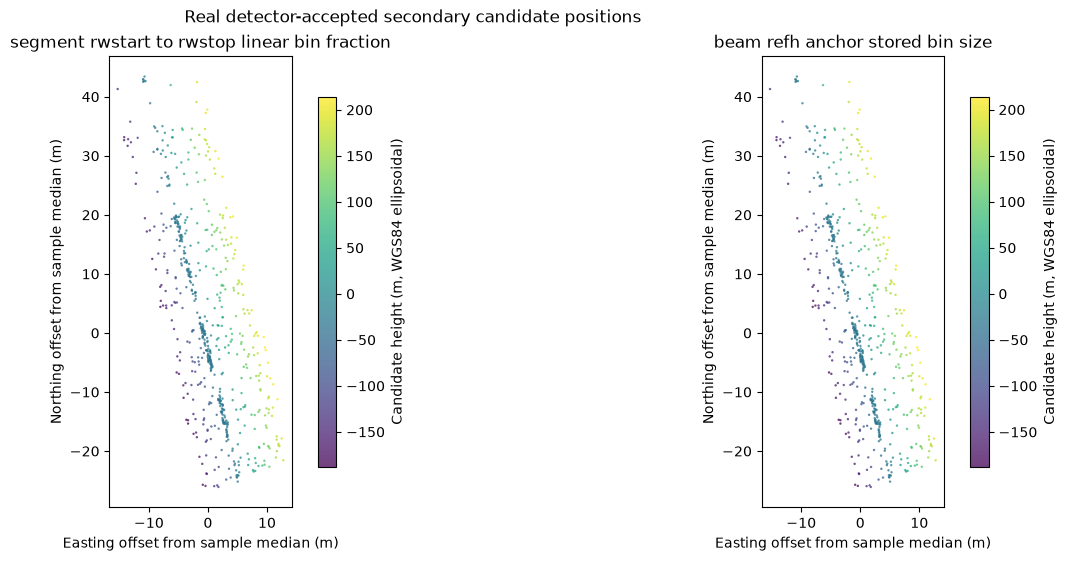

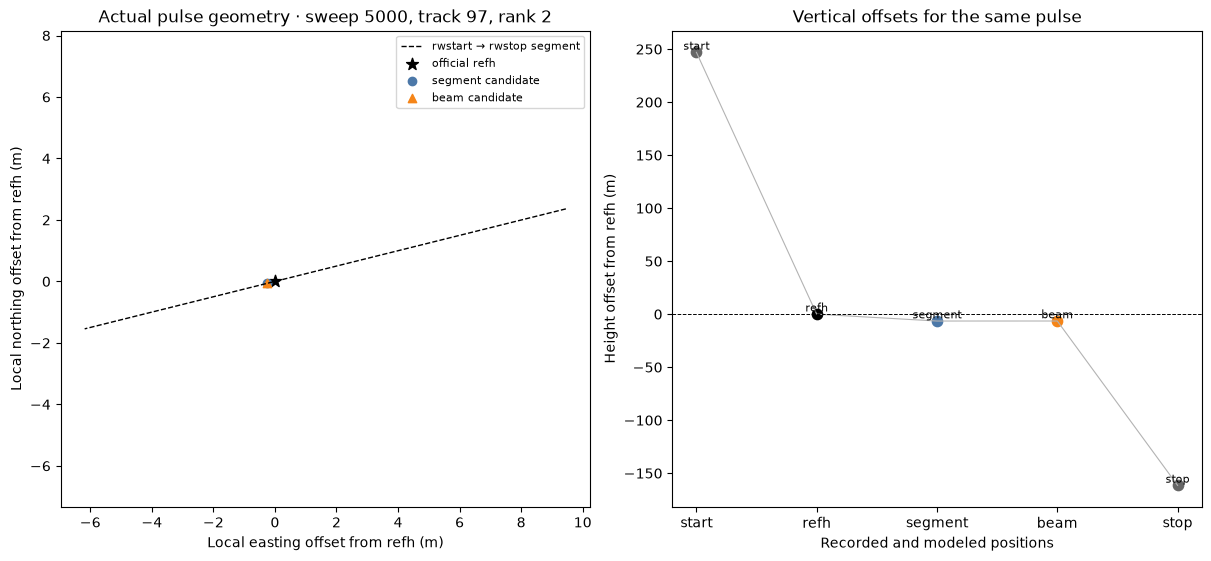

Selected accepted secondary: {'pulse_index': 1280044, 'sweep': 5000, 'track': 97, 'peak_bin': 1692.0, 'prominence': 1137.4656844986519, 'segment_height_m': -34.91566289868206, 'beam_height_m': -34.893142773769796}


In [5]:
secondary = valid[valid["is_valid_secondary_candidate"].astype(bool)].copy()
if secondary.empty:
    raise RuntimeError("No detector-accepted real secondary candidates were generated for this sample.")
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
secondary["easting_m"], secondary["northing_m"] = transformer.transform(
    secondary["candidate_lon"].to_numpy(), secondary["candidate_lat"].to_numpy())
east_center = float(secondary["easting_m"].median())
north_center = float(secondary["northing_m"].median())
secondary["easting_offset_m"] = secondary["easting_m"] - east_center
secondary["northing_offset_m"] = secondary["northing_m"] - north_center
plot_secondary = secondary.sample(min(2500, len(secondary)), random_state=42) if len(secondary) > 2500 else secondary
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
for ax, method in zip(axes, [SEGMENT_METHOD, BEAM_METHOD]):
    sub = plot_secondary[plot_secondary["geolocation_method"] == method]
    sc = ax.scatter(sub["easting_offset_m"], sub["northing_offset_m"], c=sub["candidate_height"],
                    s=3, alpha=.75, cmap="viridis", linewidths=0, rasterized=True)
    ax.set(title=method.replace("_", " "), xlabel="Easting offset from sample median (m)",
           ylabel="Northing offset from sample median (m)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, label="Candidate height (m, WGS84 ellipsoidal)", shrink=.82)
fig.suptitle("Real detector-accepted secondary candidate positions")
plt.show()

chosen = secondary.sort_values("prominence", ascending=False).iloc[0]
key = (int(chosen.pulse_index), int(chosen.component_rank))
chosen_pair = candidates[(candidates.pulse_index == key[0]) & (candidates.component_rank == key[1])]
chosen_pair = chosen_pair.set_index("geolocation_method")
with h5py.File(H5_PATH, "r") as h5:
    p = key[0]
    start_geo = (float(h5["rwstart_longitude"][p]), float(h5["rwstart_latitude"][p]), float(h5["rwstart"][p]))
    stop_geo = (float(h5["rwstop_longitude"][p]), float(h5["rwstop_latitude"][p]), float(h5["rwstop"][p]))
    refh_geo = (float(h5["refh_longitude"][p]), float(h5["refh_latitude"][p]), float(h5["refh"][p]))
    sweep, track = int(h5["sweep_num"][p]), int(h5["track_num"][p])

def local_xyz(geo):
    e, n = transformer.transform(geo[0], geo[1])
    return np.array([e, n, geo[2]])

start_xyz, stop_xyz, refh_xyz = map(local_xyz, [start_geo, stop_geo, refh_geo])
segment_geo = chosen_pair.loc[SEGMENT_METHOD, ["candidate_lon", "candidate_lat", "candidate_height"]].to_numpy(dtype=float)
beam_geo = chosen_pair.loc[BEAM_METHOD, ["candidate_lon", "candidate_lat", "candidate_height"]].to_numpy(dtype=float)
segment_xyz, beam_xyz = local_xyz(segment_geo), local_xyz(beam_geo)
origin = refh_xyz.copy()
fig = plt.figure(figsize=(12, 5.5), constrained_layout=True)
ax = fig.add_subplot(1, 2, 1)
ax.plot([start_xyz[0]-origin[0], stop_xyz[0]-origin[0]],
        [start_xyz[1]-origin[1], stop_xyz[1]-origin[1]], "k--", lw=1, label="rwstart → rwstop segment")
ax.scatter(0, 0, c="black", marker="*", s=80, label="official refh")
ax.scatter(segment_xyz[0]-origin[0], segment_xyz[1]-origin[1], c="#4c78a8", marker="o", label="segment candidate")
ax.scatter(beam_xyz[0]-origin[0], beam_xyz[1]-origin[1], c="#f58518", marker="^", label="beam candidate")
ax.set(xlabel="Local easting offset from refh (m)", ylabel="Local northing offset from refh (m)",
       title=f"Actual pulse geometry · sweep {sweep}, track {track}, rank {key[1]}")
ax.legend(fontsize=8)
ax.set_aspect("equal", adjustable="datalim")
ax2 = fig.add_subplot(1, 2, 2)
labels = ["start", "refh", "segment", "beam", "stop"]
coords = [start_xyz, refh_xyz, segment_xyz, beam_xyz, stop_xyz]
colors = ["0.4", "black", "#4c78a8", "#f58518", "0.4"]
for i, (label, xyz, color) in enumerate(zip(labels, coords, colors)):
    ax2.scatter(i, xyz[2]-origin[2], c=color, s=55)
    ax2.text(i, xyz[2]-origin[2], label, ha="center", va="bottom", fontsize=8)
ax2.plot(range(len(coords)), [xyz[2]-origin[2] for xyz in coords], color="0.7", lw=.8)
ax2.axhline(0, color="black", lw=.7, linestyle="--")
ax2.set_xticks(range(len(labels)), labels)
ax2.set(xlabel="Recorded and modeled positions", ylabel="Height offset from refh (m)", title="Vertical offsets for the same pulse")
plt.show()
print("Selected accepted secondary:", {
    "pulse_index": key[0], "sweep": sweep, "track": track,
    "peak_bin": float(chosen.peak_bin), "prominence": float(chosen.prominence),
    "segment_height_m": float(chosen_pair.loc[SEGMENT_METHOD, "candidate_height"]),
    "beam_height_m": float(chosen_pair.loc[BEAM_METHOD, "candidate_height"]),
})

## Real rejected candidates and conclusion

A finite coordinate is only a model result. The detector can reject a waveform component while both geometry methods still return finite coordinates. That distinction is shown below using the actual detector rejection reason.

In [6]:
rejected = components.loc[~components["is_main_component"].astype(bool)
                          & ~components["is_valid_secondary_candidate"].astype(bool)].copy()
if len(rejected):
    rejected = rejected.sort_values("prominence", ascending=False).head(8)
    display(rejected[["pulse_index", "sweep_num", "track_num", "component_rank", "peak_bin",
                      "prominence", "rejected_reason"]])
else:
    print("No rejected secondary component rows in the selected sample.")
invalid_by_method = candidates.groupby("geolocation_method").agg(
    candidates=("geometry_valid", "size"), geometry_valid=("geometry_valid", "sum")
).reset_index()
invalid_by_method["invalid"] = invalid_by_method["candidates"] - invalid_by_method["geometry_valid"]
display(invalid_by_method)
print("Closure uses raw RX argmax and recorded segment endpoints. It is not an external reference.")
print("Beam candidates use the official refh point as the range anchor by construction.")

,pulse_index,sweep_num,track_num,component_rank,peak_bin,prominence,rejected_reason
3036,1280702,5002,245,2,1644.0,617.675458,low_relative_prominence_to_main
1954,1280382,5001,243,2,1159.0,609.779925,low_relative_prominence_to_main
805,1280214,5000,182,2,367.0,607.033412,low_absolute_prominence
1957,1280414,5001,244,2,178.0,603.94506,low_relative_prominence_to_main
3024,1280542,5002,240,2,2309.0,590.281488,low_relative_prominence_to_main
1950,1280350,5001,242,2,1890.0,567.822284,low_relative_prominence_to_main
471,1280076,5000,98,4,240.0,550.999667,low_absolute_prominence
1766,1280501,5001,175,2,1389.0,546.794901,low_absolute_prominence


,geolocation_method,candidates,geometry_valid,invalid
0,beam_refh_anchor_stored_bin_size,3064,3064,0
1,segment_rwstart_to_rwstop_linear_bin_fraction,3064,3064,0


Closure uses raw RX argmax and recorded segment endpoints. It is not an external reference.
Beam candidates use the official refh point as the range anchor by construction.


## Scientific conclusion

For these 768 real pulses, both methods produce finite candidate coordinates for the detected component rows, and raw-argmax segment interpolation closes against official refh at centimetre-scale residuals. The two candidate models can be compared on identical pulse/component pairs; their agreement remains internal because the beam method is refh-anchored. Detector-rejected components and weak or ambiguous waveform structure remain visible. This evidence supports a reproducible candidate-generation and internal-consistency workflow, but **does not establish reliable absolute 3D locations for secondary physical returns**. Independent external labels and broader validation are still needed.